
## 22.3 XGBoost Training, Prediction & Key Parameters

### How XGBoost Training Works (Big Picture)

XGBoost training follows a disciplined correction loop:

1. Start with an initial prediction (base score)
2. Compute gradients and hessians
3. Build a tree that minimizes the objective
4. Compute optimal leaf weights
5. Update predictions using learning rate
6. Repeat until performance stops improving

> Key idea: **Each tree is weak on purpose. Strength comes from many controlled corrections.**


### Key Parameters You Must Understand

#### Core Structure
- `n_estimators`: number of trees  
- `max_depth`: depth of each tree  
- `learning_rate (eta)`: step size of updates  

Golden rule:
> High depth + high learning rate = overfitting speedrun


#### Sampling Parameters

- `subsample`: fraction of rows used per tree
- `colsample_bytree`: fraction of features used per tree

> Sampling intentionally hides data to reduce overfitting.



#### Objective Function

Examples:
- `reg:squarederror` → regression
- `binary:logistic` → binary classification
- `multi:softprob` → multiclass classification

> Wrong objective = wrong math = useless model


In [3]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [4]:
data = load_breast_cancer()
x = pd.DataFrame(data.data , columns=data.feature_names)
y= pd.Series(data.target)

In [5]:
x_train , x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2 , random_state=42, stratify=y
)

In [7]:
# default XGBoost model

model = XGBClassifier(
    n_estimates = 100,
    max_depth = 3,
    learning_rate = 0.1,
    subsample = 0.8,
    colsample_bytree = 0.8,
    objective = "binary:logistic",
    eval_metric = "logloss",
    random_state = 42
)

model.fit(x_train , y_train)

C:\Users\Tanvir Ishrak\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:41:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimates" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [8]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[: , 1]


In [9]:
print("Accuracy: ", accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))

Accuracy:  0.9649122807017544
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [10]:
print(confusion_matrix(y_test, y_pred))

[[39  3]
 [ 1 71]]


### #Early Stopping (Overfitting Control)

In [12]:
#Early Stopping (Overfitting Control)
import xgboost as xgb

dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 3,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}

modelr = xgb.train(
    params = params,
    dtrain=dtrain,
    num_boost_round=500,
    evals=[(dtest,"eval")],
    early_stopping_rounds=20
)

[0]	eval-logloss:0.61842
[1]	eval-logloss:0.58321
[2]	eval-logloss:0.55082
[3]	eval-logloss:0.52073
[4]	eval-logloss:0.49467
[5]	eval-logloss:0.46962
[6]	eval-logloss:0.44566
[7]	eval-logloss:0.42481
[8]	eval-logloss:0.40613
[9]	eval-logloss:0.38876
[10]	eval-logloss:0.37057
[11]	eval-logloss:0.35528
[12]	eval-logloss:0.34206
[13]	eval-logloss:0.32877
[14]	eval-logloss:0.31728
[15]	eval-logloss:0.30600
[16]	eval-logloss:0.29463
[17]	eval-logloss:0.28420
[18]	eval-logloss:0.27308
[19]	eval-logloss:0.26355
[20]	eval-logloss:0.25420
[21]	eval-logloss:0.24586
[22]	eval-logloss:0.23860
[23]	eval-logloss:0.23042
[24]	eval-logloss:0.22197
[25]	eval-logloss:0.21612
[26]	eval-logloss:0.21087
[27]	eval-logloss:0.20603
[28]	eval-logloss:0.20119
[29]	eval-logloss:0.19567
[30]	eval-logloss:0.19133
[31]	eval-logloss:0.18624
[32]	eval-logloss:0.18076
[33]	eval-logloss:0.17652
[34]	eval-logloss:0.17227
[35]	eval-logloss:0.16889
[36]	eval-logloss:0.16478
[37]	eval-logloss:0.16107
[38]	eval-logloss:0.15

In [14]:
y_prob = modelr.predict(dtest)

y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print("Accuracy: ", acc)

print(classification_report(y_test, y_pred))

Accuracy:  0.9649122807017544
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [18]:
print("Early Stopping Information: ")
print("Best Iteration:", modelr.best_iteration)
print("Best score [logloss]: ", modelr.best_score)  # ei valuer por logloss bartei ache

Early Stopping Information: 
Best Iteration: 151
Best score [logloss]:  0.090749506343344


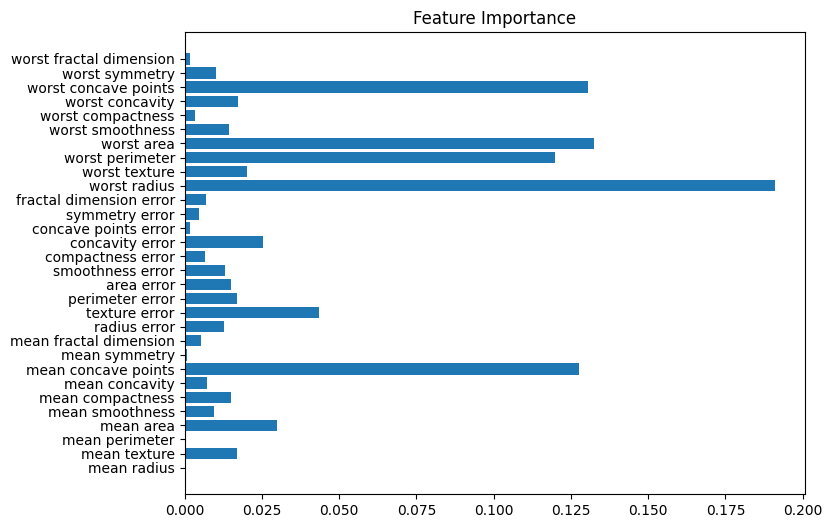

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(x.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.show()